# 1. Introduction to Neural Networks

In [ ]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/deeplearning.udea/main/content/init.py
import init; init.init(force_download=False); 

Artificial Neural Networks (ANNs) are bioinspired algorithms that address a wide range of problems in machine learning. ANNs aim to emulate the behavior and learning capabilities of biological neural networks; they are built from a structure composed of many basic units (neurons) called **perceptrons**, which, in conjunction, can solve complex problems. 

ANNs can be used for various learning paradigms, but in most common scenarios, they are employed as a mapping $x \rightarrow y$ from an input space $x \in \mathcal{X}$ to an output space $y \in \mathcal {Y}$. Depending on the application, $x$ and $y$ can be samples from different information modalities such as vectors, matrices, images, videos, or audio signals. Therefore, the study of neural networks involves analyzing the most appropriate architectures (neural configurations) for each modality and task, as well as the essential components required for successful model training and deployment.

## 1.1 The Perceptron

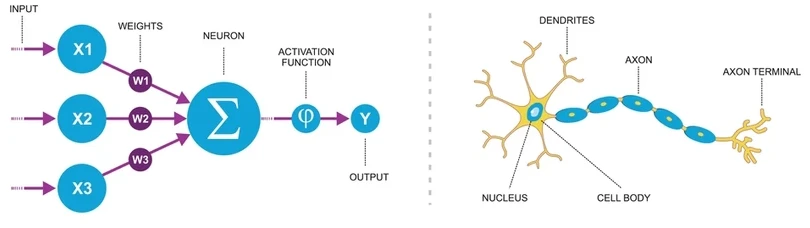

In [2]:
from IPython.display import Image
Image(filename='local/imgs/perceptron.webp')

As the diagram states, $x_i$ corresponds to an input variable. The whole set of input variables is typically expressed as a vector ${\bf{x}}=\{x_1,x_2,\cdots,x_d\}$.

Each $w_i$ is a real constant or weight that determines the contribution of the input $x_i$ to the perceptron's output, and $\phi$ is the activation function. In its simplest form, the activation function is just the sign function, so that the output of the perceptron would be:

$$y = \left\{
                \begin{array}{ll}
                  1\;\;\;{\rm{if}}\;\;\;w_0  + w_1 x_1  + w_2 x_2  +  \cdots  + w_d x_d  > 0\\
                  0\;\;{\rm{\text{other wise}}}
                \end{array}
              \right. $$
**Note** that even though there is no $w_0$ in the former figure, the bias term is always present and highly relevant. $−w_ 0$ is the threshold that the combination $w_1x_1 + w_2x_2 + \cdots + w_d x_d \;$ must overpass in order to get an output equal to 1. 

By assuming an additional input $x_0 = 1$, an using the sign function ($sgn$), the perceptron can alternatively be expressed as:

$$y({\bf{x}}) = sgn\left(\sum_{i=0}^{d} w_ix_i \right) = sgn({\bf{w}}^T{\bf{x}})$$

where the vector ${\bf{w}}=\{w_0,w_1,w_2,\cdots,w_d\}$.

However, since the sign function is nondifferentiable and prevents the use of gradient-based optimization algorithms for model training, it must be preplaced. The first option is to use an alternative that emulates the behavior of the sign function but continuously: the sigmoid or logistic function.

$$
g(u) = \frac{\exp(u)}{1 + \exp(u)}
$$

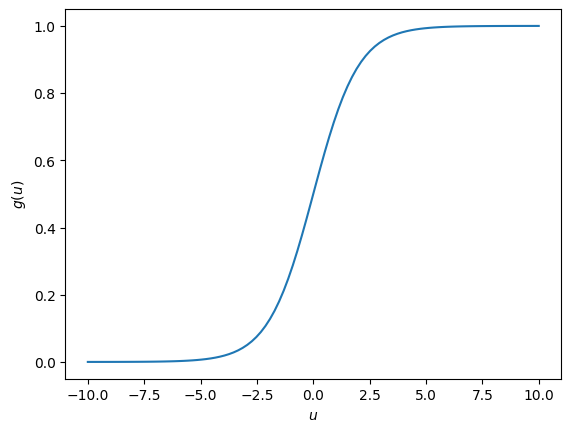

In [2]:
import numpy as np
import matplotlib.pyplot as plt
u=np.linspace(-10,10,100)
g = np.exp(u)/(1 + np.exp(u))
plt.plot(u,g)
plt.xlabel('$u$')
plt.ylabel('$g(u)$')
plt.show()

So, the perceptron can be mathematically expressed as:

$$y({\bf{x}})=g({\bf{w}}^T{\bf{x}}) = \frac{\exp({\bf{w}}^T{\bf{x}})}{1 + \exp({\bf{w}}^T{\bf{x}})} = \frac{1}{1+\exp(-{\bf{w}}^T{\bf{x}})}$$

and is equivalent to the model known as **Logistic Regression**.

We might know from our previous courses in statistics or classical Machine Learning, that a Logistic Regression is able to solve problems that look like:

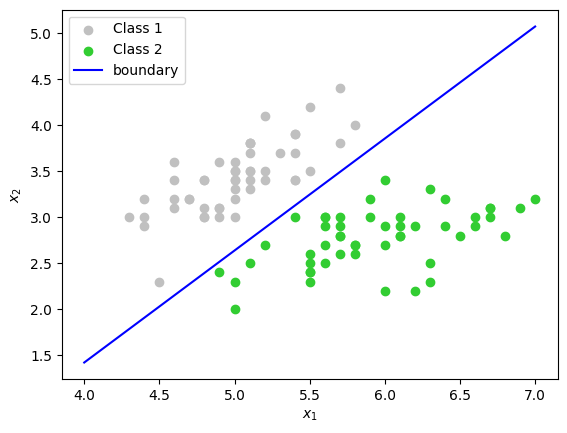

In [1]:
from local.lib.utils import plot_perceptron_frontier
plot_perceptron_frontier()

**Now let's thing about the following problem:**

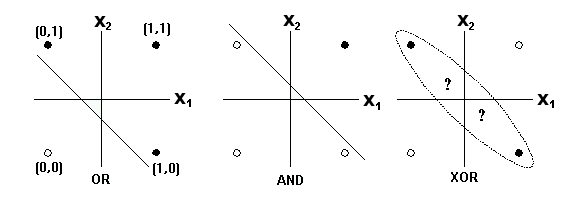

In [3]:
Image(filename='local/imgs/ORANDXOR.png', width=600)

<span style="color:red">**One single perceptron is not able to solve the problem!**</span>  

But we know that XOR can be reconstructed by using two AND and one OR functions

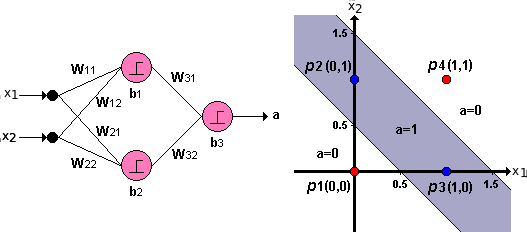

In [4]:
Image(filename='local/imgs/XOR.png', width=600)

<span style="color:blue">**This is a neural network!**</span> 

## 1.2 Multi-layer perceptron (MLP)

In order to solve more complex problems, several perceptrons can be used together forming what is call a multi-layer perceptron.

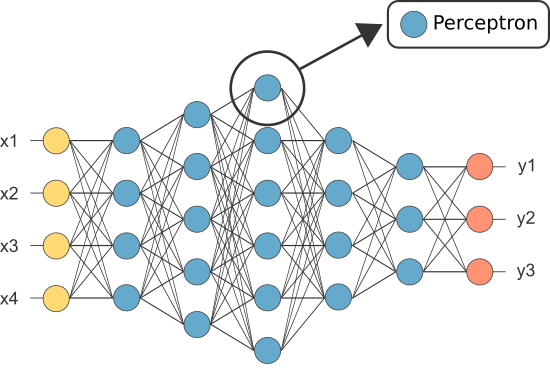

In [5]:
Image(filename='local/imgs/MLP_.png', width=600)

The output $k$ of an MLP with one input layer and one hidden layer can be expressed as:

$$
y_{jk}({\bf{x}}_j,{\bf{w}}) = \sigma\left( \sum_{l=1}^{M_1} w_{kl}^{(2)} h \left( \sum_{i=1}^{d} w_{li}^{(1)} x_{ji} + w_{l0}^{(1)} \right) + w_{k0}^{(2)}\right) 
$$

where $\sigma$ and $h$ are the activation functions for the output and hidden layers, respectively. Placing a sample ${\bf{x}}_j$ at the input of the network and propagating its value through all the neurons and layers until getting the output $y_{jk}({\bf{x}}_j,{\bf{w}})$ is called the **forward pass**.

## 1.3 Training of Artificial Neural Networks